<a href="https://colab.research.google.com/github/mustafafawzyzaki/convert_pdf_to_dicom/blob/main/WF_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib numpy

## # Import the Libraries to begin the code



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import the Dataset

In [ ]:

df = pd.read_csv('/content/sample_data/train (2).csv')


In [ ]:
df.info()       #data type/ count / null


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [ ]:
df.describe(include='all') #Data Descriptive


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,20758.00000,20758,20758.000000,20758.000000,20758.000000,20758,20758,20758.000000,20758.000000,20758,20758,20758.000000,20758,20758.000000,20758.000000,20758,20758,20758
unique,NaN,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,3,5,7
top,NaN,Female,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_III
freq,NaN,10422,NaN,NaN,NaN,17014,18982,NaN,NaN,17529,20513,NaN,20071,NaN,NaN,15066,16687,4046
mean,10378.50000,NaN,23.841804,1.700245,87.887768,NaN,NaN,2.445908,2.761332,NaN,NaN,2.029418,NaN,0.981747,0.616756,NaN,NaN,NaN
std,5992.46278,NaN,5.688072,0.087312,26.379443,NaN,NaN,0.533218,0.705375,NaN,NaN,0.608467,NaN,0.838302,0.602113,NaN,NaN,NaN
min,0.00000,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,5189.25000,NaN,20.000000,1.631856,66.000000,NaN,NaN,2.000000,3.000000,NaN,NaN,1.792022,NaN,0.008013,0.000000,NaN,NaN,NaN
50%,10378.50000,NaN,22.815416,1.700000,84.064875,NaN,NaN,2.393837,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.573887,NaN,NaN,NaN
75%,15567.75000,NaN,26.000000,1.762887,111.600553,NaN,NaN,3.000000,3.000000,NaN,NaN,2.549617,NaN,1.587406,1.000000,NaN,NaN,NaN


## Investigate missing data...

In [ ]:
missing_values = df.isnull().sum()    #Defining missing values...
missing_values        #There are no missing values

,0
id,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0


## Duplicate Detection and Handling...

In [ ]:
# detecttion od duplicates...
df.duplicated().sum()
# Masking duplicates
detected_dup = df.duplicated(keep=False)
# Extract duplicate rows
duplicates = df[detected_dup]


duplicates.head(5)

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad


In [ ]:
#Handling of Duplicates...
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
#df.drop(["Weight","Height",'NCP'], axis=1, inplace=True)

In [ ]:
""" Explore Target Alignment with the actual BMI"""
"""df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['NObeyesdad'] = df['NObeyesdad'].replace({'Overweight_Level_I': 'Overweight', 'Overweight_Level_II': 'Overweight',
                                                             'Obesity_Type_I':'Obese', 'Obesity_Type_II': 'Obese', 'Obesity_Type_III': 'Obese'})

# 2. Define mapping from BMI to obesity classes (using WHO thresholds + your dataset's labels)
def bmi_to_label(bmi):
    if bmi < 18.5:
        return 'Insufficient_Weight'
    elif bmi < 25:
        return 'Normal_Weight'
    elif bmi < 30:
        return 'Overweight'

    else:
        return 'Obese'   # dataset has Type_II and Type_III

# 2. Define mapping from BMI to obesity classes (using WHO thresholds + your dataset's labels)
def bmi_to_label(bmi):
    if bmi < 18.5:
        return 'Insufficient_Weight'
    elif bmi < 25:
        return 'Normal_Weight'
    elif bmi < 30:
        return 'Overweight'
    elif bmi < 35:
        return 'Obesity_Type_I'
    elif bmi < 40:
        return 'Obesity_Type_II'
    else:
        return 'Obesity_Type_III'   # dataset has Type_II and Type_III

df['BMI_Label'] = df['BMI'].apply(bmi_to_label)

# 3. Compare actual label with BMI-derived label
true_label = df['NObeyesdad']
bmi_label = df['BMI_Label']
match = (true_label == bmi_label)

# Percentage of consistent rows
match_percentage = match.mean() * 100
print(f"Percentage of rows where label matches BMI category: {match_percentage}%")
print(f"Total mismatched rows: {(~match).sum()} out of {len(df)}")

print("\nCross-tabulation (True label vs BMI category):")
ct = pd.crosstab(true_label, bmi_label, margins=True)
print(ct)

#  Identify mismatched rows
mismatched = df[~match]
print(f"\nFirst 5 mismatched rows:")
print(mismatched[['Height', 'Weight', 'BMI', 'NObeyesdad', 'BMI_Label']].head())


# Create a corrected column: keep original if match, else use BMI_Label
df['corrected'] = df['NObeyesdad']
df.loc[~match, 'corrected'] = df.loc[~match, 'BMI_Label']

# Check how many labels changed
changed = (df['corrected'] != df['NObeyesdad']).sum()
print(f"\nNumber of labels corrected: {changed}")

# Percentage of corrected labels
print(f"Corrected {changed/len(df)*100}% of the dataset")

df.drop(['BMI', 'NObeyesdad'], axis=1, inplace=True)
df.drop('BMI_Label', axis=1, inplace=True)"""

'df[\'BMI\'] = df[\'Weight\'] / (df[\'Height\'] ** 2)\ndf[\'NObeyesdad\'] = df[\'NObeyesdad\'].replace({\'Overweight_Level_I\': \'Overweight\', \'Overweight_Level_II\': \'Overweight\',\n                                                             \'Obesity_Type_I\':\'Obese\', \'Obesity_Type_II\': \'Obese\', \'Obesity_Type_III\': \'Obese\'})\n\n# 2. Define mapping from BMI to obesity classes (using WHO thresholds + your dataset\'s labels)\ndef bmi_to_label(bmi):\n    if bmi < 18.5:\n        return \'Insufficient_Weight\'\n    elif bmi < 25:\n        return \'Normal_Weight\'\n    elif bmi < 30:\n        return \'Overweight\'\n\n    else:\n        return \'Obese\'   # dataset has Type_II and Type_III\n\n# 2. Define mapping from BMI to obesity classes (using WHO thresholds + your dataset\'s labels)\ndef bmi_to_label(bmi):\n    if bmi < 18.5:\n        return \'Insufficient_Weight\'\n    elif bmi < 25:\n        return \'Normal_Weight\'\n    elif bmi < 30:\n        return \'Overweight\'\n    

## Exploring visually some Features...


## Visualizing percetages of different Obesity levels...


/tmp/ipykernel_5109/3467654455.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Obesity_Level', y='Percentage', data=obesity_df, palette='viridis')


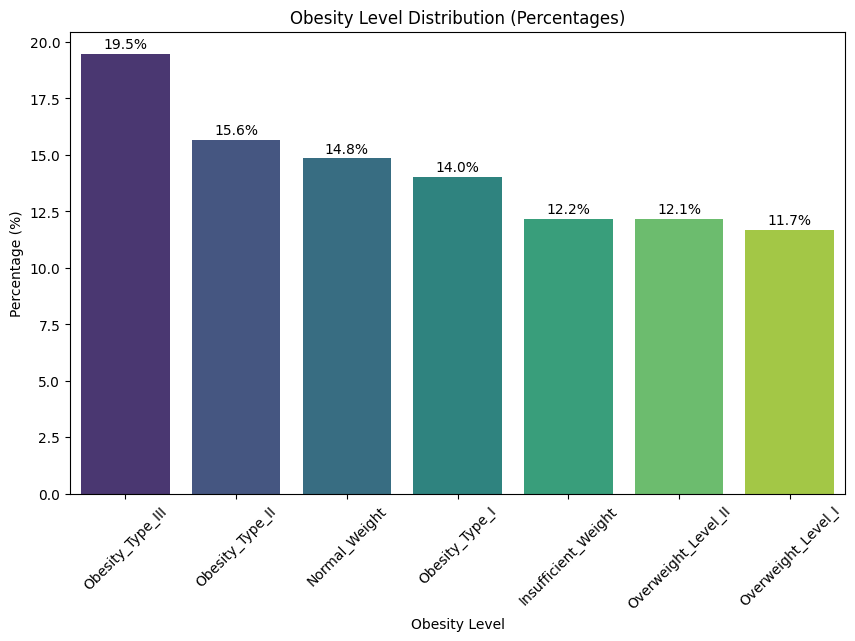

Obesity Level Percentages:

Obesity_Type_III: 19.49%
Obesity_Type_II: 15.65%
Normal_Weight: 14.85%
Obesity_Type_I: 14.02%
Insufficient_Weight: 12.15%
Overweight_Level_II: 12.15%
Overweight_Level_I: 11.69%


In [ ]:
# Visualizing percetages of different Obesity levels...

# Calculate percentages
obesity_percentages = df['NObeyesdad'].value_counts(normalize=True) * 100

# Convert to DataFrame for plotting
obesity_df = obesity_percentages.reset_index()
obesity_df.columns = ['Obesity_Level','Percentage']

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x='Obesity_Level', y='Percentage', data=obesity_df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Obesity Level Distribution (Percentages)')
plt.ylabel('Percentage (%)')
plt.xlabel('Obesity Level')

# Annotate percentages on bars
for index, row in obesity_df.iterrows():
    plt.text(index, row['Percentage'] + 0.25, f"{row['Percentage']:.1f}%", ha='center')

plt.show()

# Print results
print("Obesity Level Percentages:\n")
for level, pct in obesity_percentages.items():
  print(f"{level}: {pct:.2f}%")


## Visualizing Gender percentages


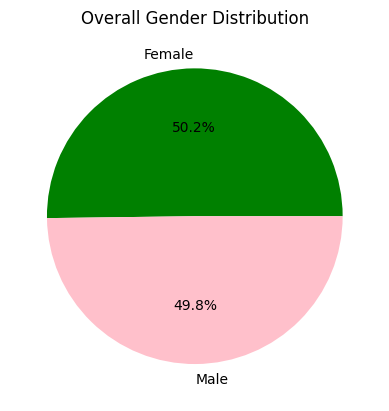

In [ ]:
## Visualizing Gender percentages

gender_counts = df["Gender"].value_counts(normalize=True) * 100
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=["green","pink"])
plt.title("Overall Gender Distribution")
plt.show()


## Visualizing percetages of Male/Female per each Obesity level...

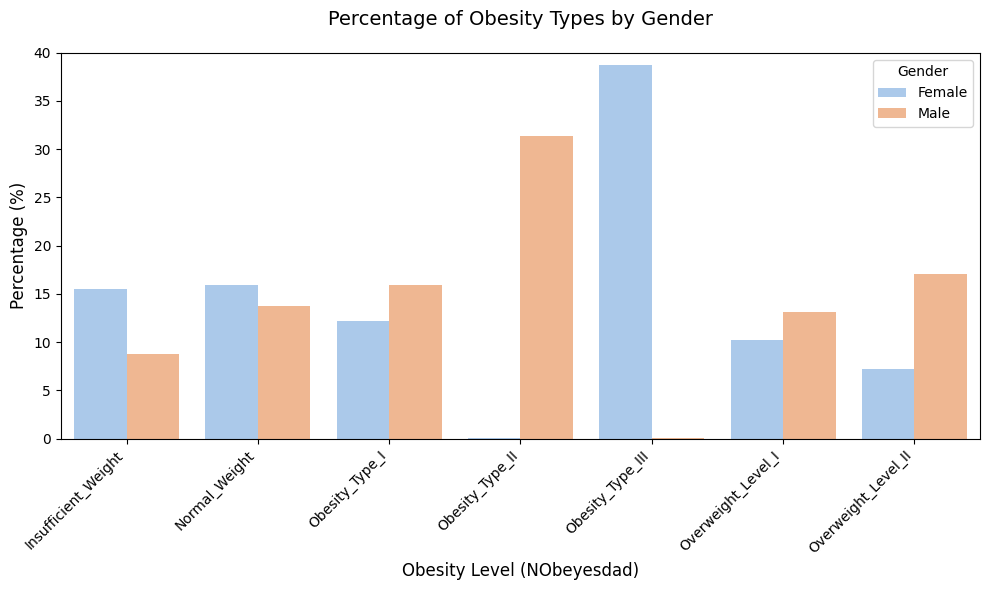

,Gender,NObeyesdad,count,percentage
0,Female,Insufficient_Weight,1621,15.553637
1,Female,Normal_Weight,1660,15.927845
2,Female,Obesity_Type_I,1267,12.156976
3,Female,Obesity_Type_II,8,0.076761
4,Female,Obesity_Type_III,4041,38.773748
5,Female,Overweight_Level_I,1070,10.266743
6,Female,Overweight_Level_II,755,7.244291
7,Male,Insufficient_Weight,902,8.726780
8,Male,Normal_Weight,1422,13.757740
9,Male,Obesity_Type_I,1643,15.895898


In [ ]:
## Visualizing percetages of Male/Female per each Obesity level...


# Get total count per gender
gender_totals = df.groupby("Gender").size()

# Create gender_obesity DataFrame by grouping and counting
gender_obesity = df.groupby(["Gender", "NObeyesdad"]).size().reset_index(name="count")

# Map each row's gender to its total, then compute %
gender_obesity["percentage"] =  (gender_obesity["count"] / gender_obesity["Gender"].map(gender_totals)) *100


# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=gender_obesity,
            x="NObeyesdad",
            y="percentage",
            hue="Gender",
            palette="pastel",
            linewidth=0.5)

plt.xticks(rotation=45, ha='right')
plt.title("Percentage of Obesity Types by Gender", fontsize=14, pad=20)
plt.xlabel("Obesity Level (NObeyesdad)", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(0, 40)
plt.legend(title="Gender", loc="upper right")

plt.tight_layout()
plt.show()
gender_obesity

## Exploring visually distribution of Numeric data and Outliers...


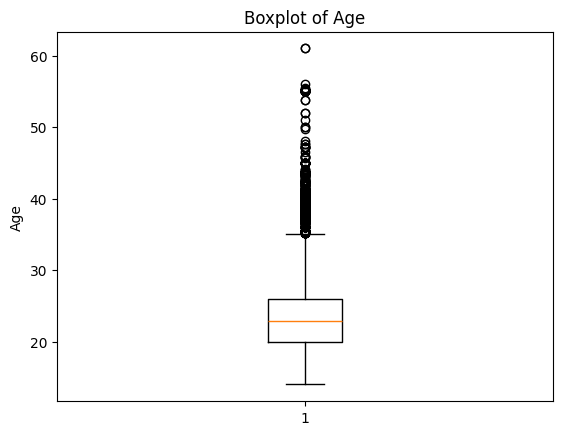

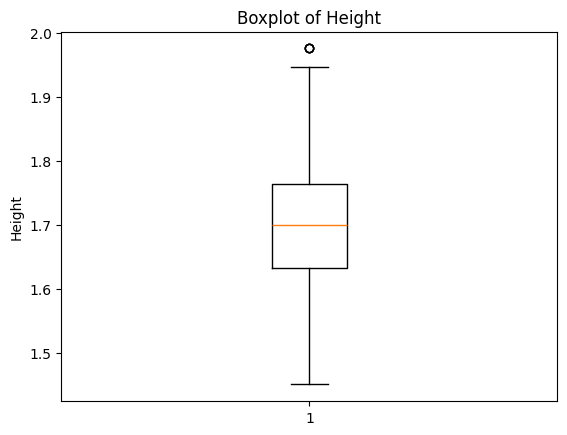

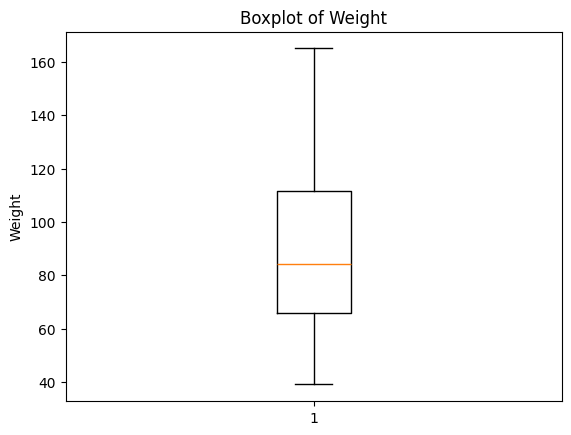

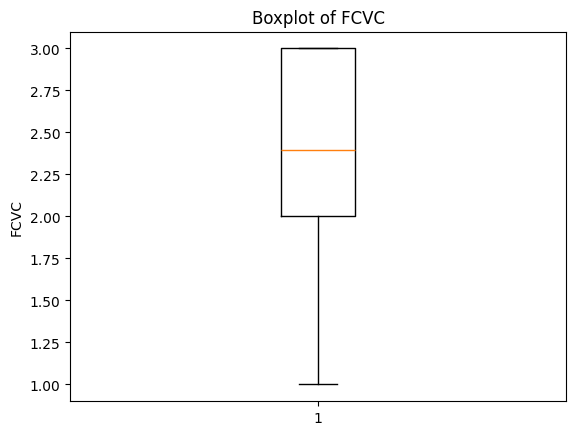

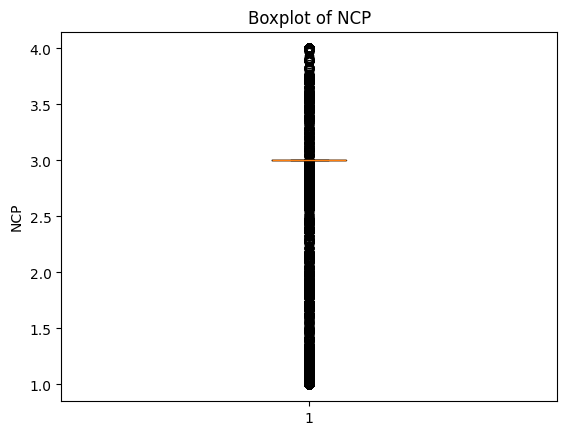

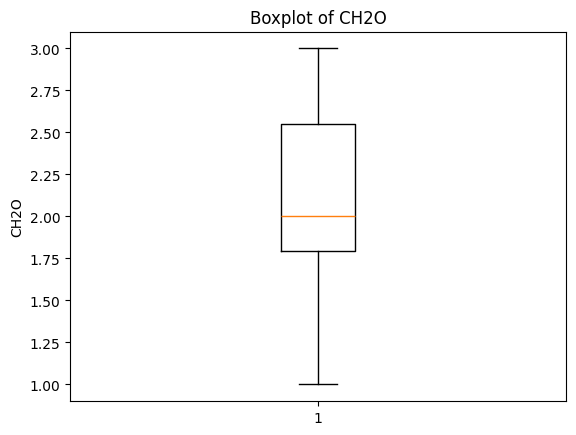

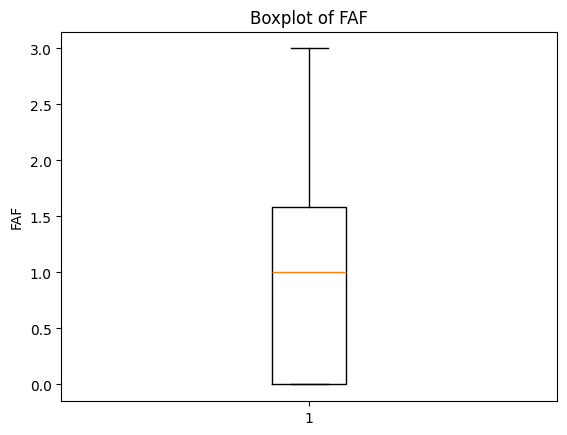

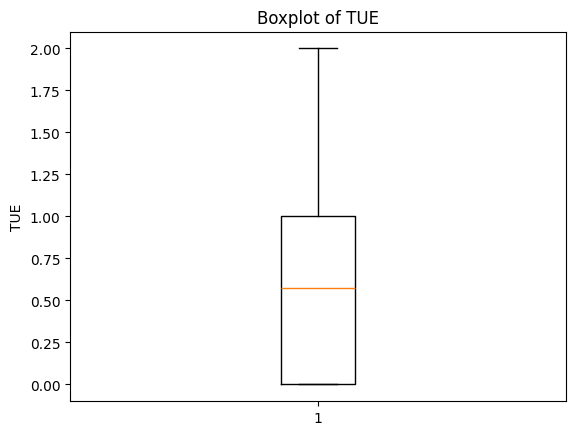

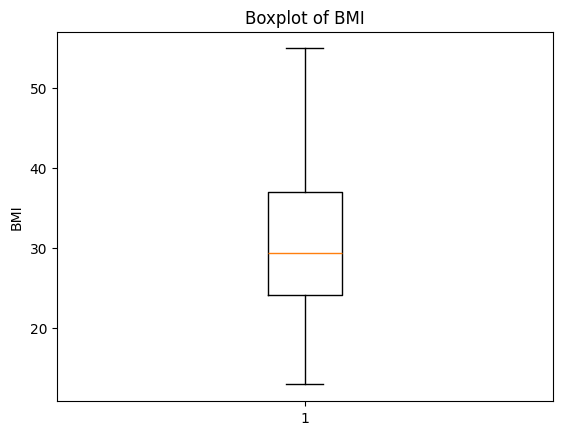

In [ ]:
#extracting numeric columns
numeric_cols = df.select_dtypes(include='float').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


## Boxplots' inspection reveals the presence of heavy outliers in Age.

# Age outlier handling

In [ ]:
Q1 = df['Age'].quantile(0.25)   #defining Firest quartile...
Q3 = df['Age'].quantile(0.75)   # defining Third quartile...
IQR = Q3 - Q1                   #defining interquartile range...

print (Q1, Q3, IQR)

lower = Q1 - 1.5 * IQR          #defining Lower Boundary For Clipping
upper = Q3 + 1.5 * IQR          #defining Upper Boundary For clipping

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]  #Defining cases outside clipping boudaries
print("Number of outliers:", len(outliers))
print(outliers['Age'].head())


20.0 26.0 6.0
Number of outliers: 1074
25    41.318302
48    37.000000
56    55.272573
80    38.098745
83    38.000000
Name: Age, dtype: float64


## Windsor method to msk observations outside defined boundaries...
### masking outliers with upper and lower values...

In [ ]:
df['Age'] = df['Age'].clip(lower, upper) # Windsor clipping
df


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II,28.259565
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight,23.422091
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight,17.126706
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III,44.855798
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II,25.599151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II,36.587084
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight,17.099278
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II,31.889841
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II,28.899693


### cheking Ouliers after Handling them...

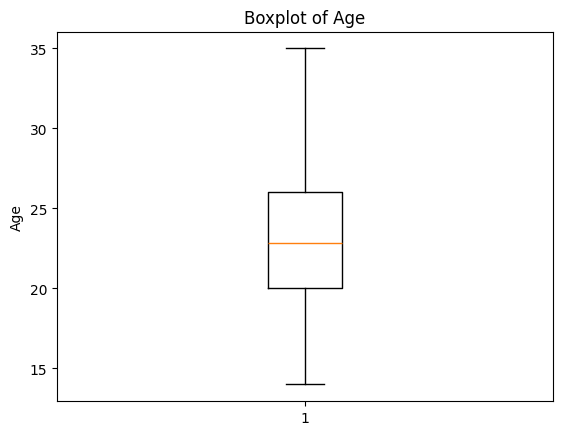

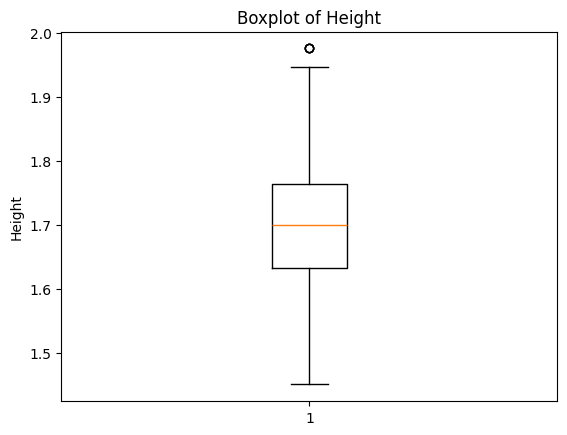

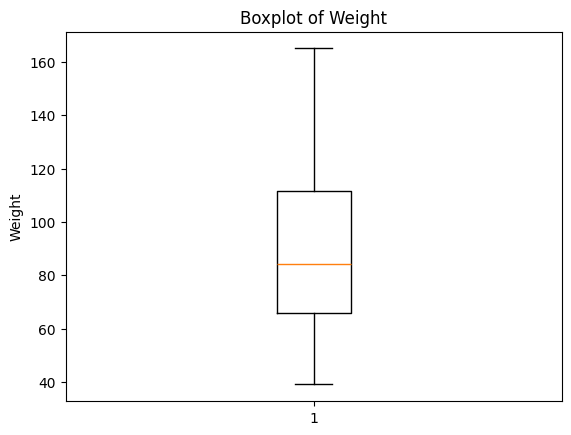

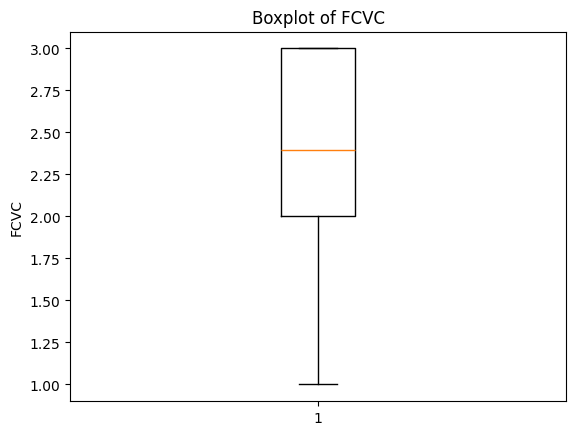

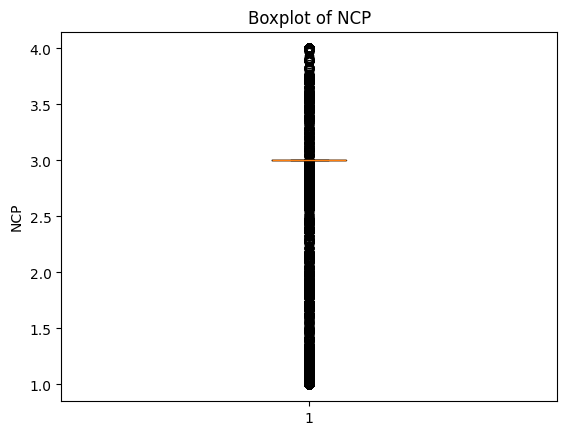

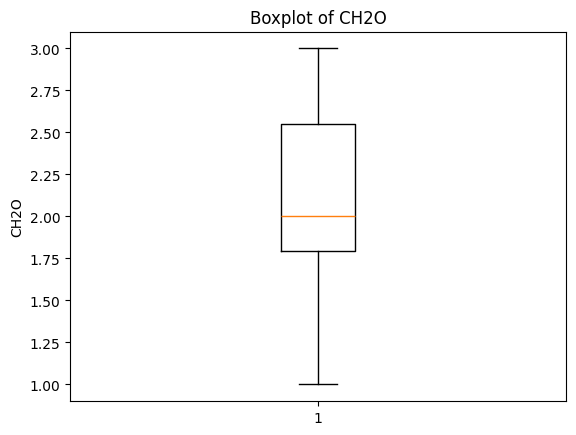

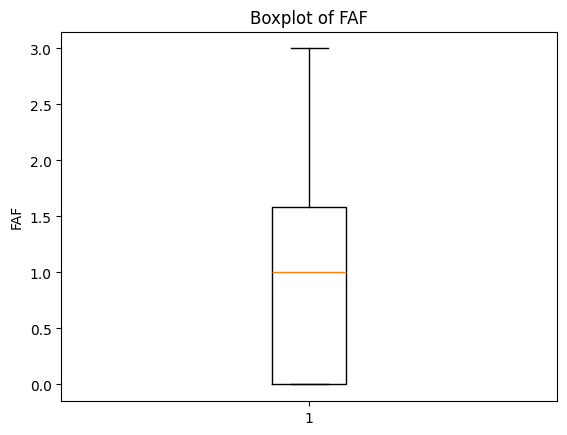

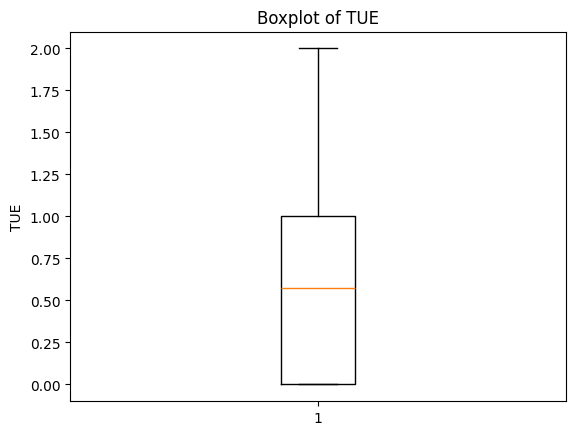

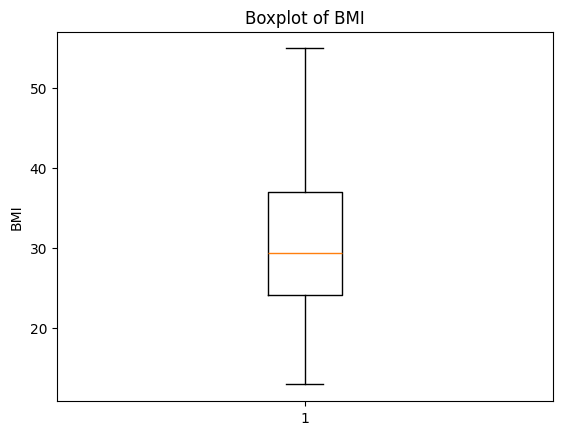

In [ ]:
for col in numeric_cols:      #cheking Outliers after dealing with them...
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


## Encoding Binary and Categorical Features...

In [ ]:
# import encoder libraries...
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [ ]:

#MAking a copy of DataFrame...
df_encoded = df.copy()

# Aggregate 'Overweight_Level_I' and 'Overweight_Level_II' into 'Overweight'
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].replace({'Overweight_Level_I': 'Overweight', 'Overweight_Level_II': 'Overweight',
                                                             'Obesity_Type_I':'Obese', 'Obesity_Type_II': 'Obese', 'Obesity_Type_III': 'Obese'})

#Label Encoding for the categorical Obesity Grade and Binary Features...
le = LabelEncoder()
df_encoded['NObeyesdad'] = le.fit_transform(df_encoded['NObeyesdad'])
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded['family_history_with_overweight'] = le.fit_transform(df_encoded['family_history_with_overweight'])
df_encoded['FAVC'] = le.fit_transform(df_encoded['FAVC'])
df_encoded['SMOKE'] = le.fit_transform(df_encoded['SMOKE'])
df_encoded['SCC'] = le.fit_transform(df_encoded['SCC'])

#OneHot Encoding for Categorical Features...
ohe = OneHotEncoder(drop="first", sparse_output=False)

cat_cols = ['CAEC', 'CALC', 'MTRANS']
encoded_array = ohe.fit_transform(df_encoded[cat_cols])

encoded_df = pd.DataFrame(
             encoded_array,
             columns=ohe.get_feature_names_out(cat_cols),
             index=df_encoded.index)

''' concatinating one hot encoded array of Categorical Features
    to the main encoded DateFrame...'''

df_encoded = pd.concat(
             [df_encoded.drop(columns=cat_cols), encoded_df],axis=1)

# scaling numerical features
"""scaler = StandardScaler()
df_encoded[['Height', 'Weight', 'FCVC', 'NCP', 'Age']] = scaler.fit_transform(df_encoded[['Height', 'Weight', 'FCVC', 'NCP', 'Age']])"""


"scaler = StandardScaler()\ndf_encoded[['Height', 'Weight', 'FCVC', 'NCP', 'Age']] = scaler.fit_transform(df_encoded[['Height', 'Weight', 'FCVC', 'NCP', 'Age']])"

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  int64  
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   SMOKE                           20758 non-null  int64  
 10  CH2O                            20758 non-null  float64
 11  SCC                             20758 non-null  int64  
 12  FAF                             

In [ ]:
df_encoded.drop('id', axis=1, inplace=True)
df_encoded

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,...,BMI,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,0,2.763573,...,28.259565,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,0,2.000000,...,23.422091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,0,1.910378,...,17.126706,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,0,1.674061,...,44.855798,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,0,1.979848,...,25.599151,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,1,25.137087,1.766626,114.187096,1,1,2.919584,3.000000,0,2.151809,...,36.587084,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
20754,1,18.000000,1.710000,50.000000,0,1,3.000000,4.000000,0,1.000000,...,17.099278,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
20755,1,20.101026,1.819557,105.580491,1,1,2.407817,3.000000,0,2.000000,...,31.889841,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
20756,1,33.852953,1.700000,83.520113,1,1,2.671238,1.971472,0,2.144838,...,28.899693,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Defining correlation between Features and the Target [NObeysdad], and the intercorreltion between them...

In [ ]:
df_encoded_cleaned = df_encoded.copy()


# Convert problematic object columns to numeric, coercing errors to NaN
#for col in ['Height', 'FCVC', 'NCP']:
  #  df_encoded_cleaned[col] = pd.to_numeric(df_encoded_cleaned[col], errors='coerce')

# Drop rows with NaN values that resulted from the coercion
df_encoded_cleaned = df_encoded_cleaned.dropna()

# correlation Matrix
correlation_matrix = df_encoded_cleaned.corr(method='spearman')
correlation_matrix

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,...,BMI,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
Gender,1.000000,0.057614,0.636527,0.148693,0.095786,0.021812,-0.365950,-0.043663,0.063349,0.061628,...,-0.080827,-0.067491,0.046738,0.025167,-0.078786,0.061115,0.022265,0.015955,-0.168146,0.062676
Age,0.057614,1.000000,0.016334,0.441574,0.331573,0.088534,0.097656,-0.120722,0.059824,0.092981,...,0.478447,-0.230014,0.246054,-0.052000,0.125966,-0.136476,0.003963,0.005346,-0.389762,-0.101989
Height,0.636527,0.016334,1.000000,0.420235,0.223471,0.111198,-0.114529,0.108902,0.060158,0.187711,...,0.093049,-0.100514,0.125341,-0.088006,0.063525,-0.080527,0.014300,0.003868,-0.087101,0.040920
Weight,0.148693,0.441574,0.420235,1.000000,0.519719,0.230225,0.224687,-0.021595,0.041007,0.348917,...,0.933011,-0.400578,0.430689,-0.087710,0.261879,-0.253290,-0.021576,-0.024159,0.030482,-0.098478
family_history_with_overweight,0.095786,0.331573,0.223471,0.519719,1.000000,0.152154,0.036052,-0.035629,0.018782,0.197555,...,0.504783,-0.294439,0.323786,-0.137835,0.009652,-0.003704,-0.026278,-0.006291,-0.060354,-0.088520
FAVC,0.021812,0.088534,0.111198,0.230225,0.152154,1.000000,0.003356,-0.009656,-0.016009,0.049394,...,0.216571,-0.125229,0.134832,-0.015150,0.116595,-0.104096,-0.027491,-0.023162,0.035871,-0.118515
FCVC,-0.365950,0.097656,-0.114529,0.224687,0.036052,0.003356,1.000000,0.133699,-0.012078,0.107123,...,0.299906,0.026022,0.012144,-0.079371,0.179202,-0.172638,-0.009972,0.006770,0.104539,-0.001100
NCP,-0.043663,-0.120722,0.108902,-0.021595,-0.035629,-0.009656,0.133699,1.000000,0.011222,0.082621,...,-0.042837,0.112796,-0.094072,-0.084923,0.105822,-0.111517,0.007087,0.005875,-0.003466,0.061263
SMOKE,0.063349,0.059824,0.060158,0.041007,0.018782,-0.016009,-0.012078,0.011222,1.000000,-0.023353,...,0.013054,0.003889,-0.009710,-0.008882,0.019179,-0.022637,0.029815,0.026625,-0.023537,-0.001540
CH2O,0.061628,0.092981,0.187711,0.348917,0.197555,0.049394,0.107123,0.082621,-0.023353,1.000000,...,0.314083,-0.161081,0.137389,0.042426,0.101478,-0.102643,0.014560,0.006820,0.053406,0.011507


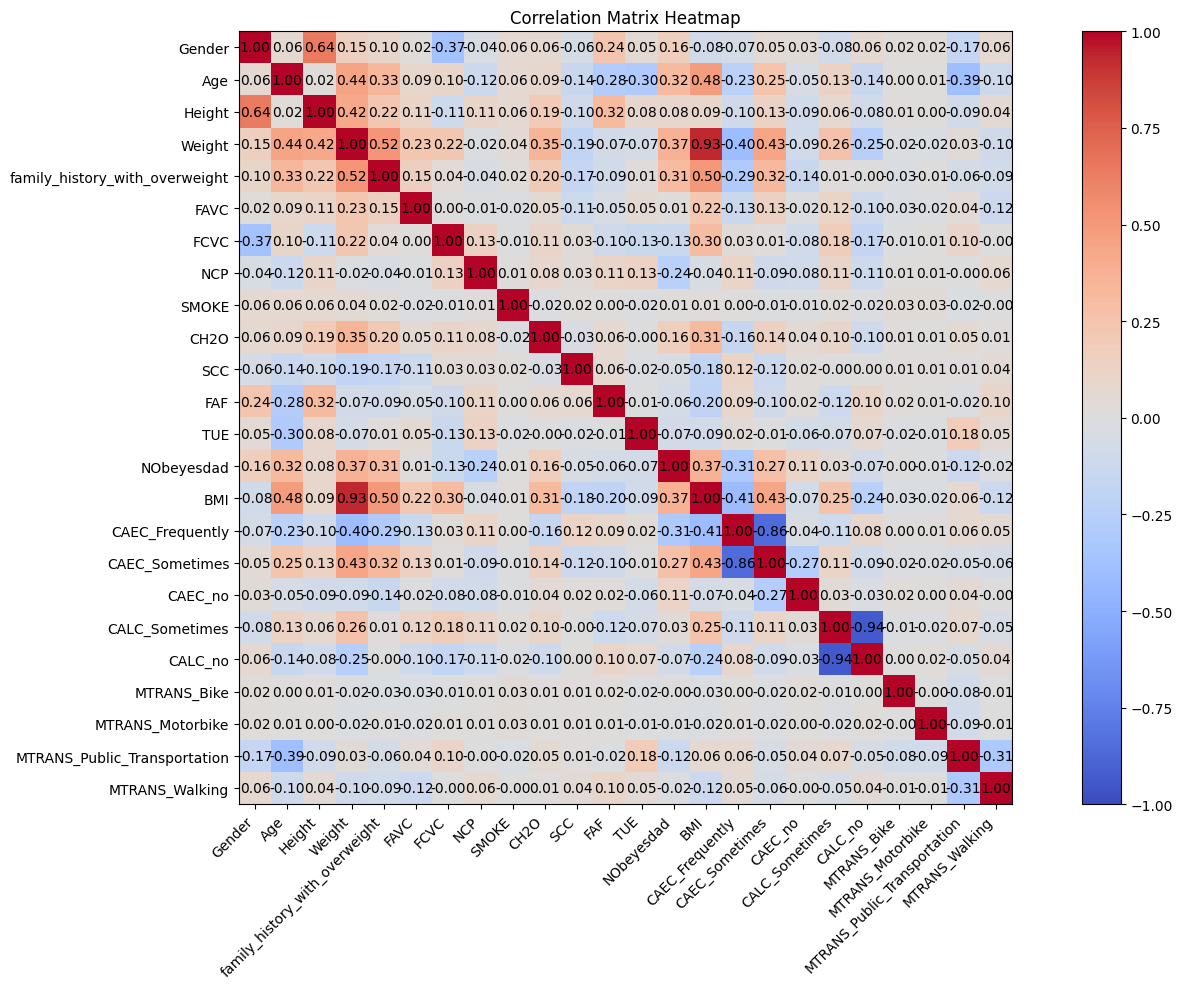

In [ ]:
# correlation Matrix Visualisation using Heatmap...
corr  = correlation_matrix
fig, ax = plt.subplots(figsize=(15, 10))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix Heatmap')
fig.tight_layout()
plt.show()


# Highly  inter-correlated Pairs [Exclude relation with the Target Feature]:
- Height/weight : 0.46
- Calc-no/calc-sometimes: 0.93
- CACE-frequently/CACE-sometimes :0.81
- Family_history/ Weight :0.5

## Construction of BMI and dropping Height and Weight

## Dropping Height and Weight

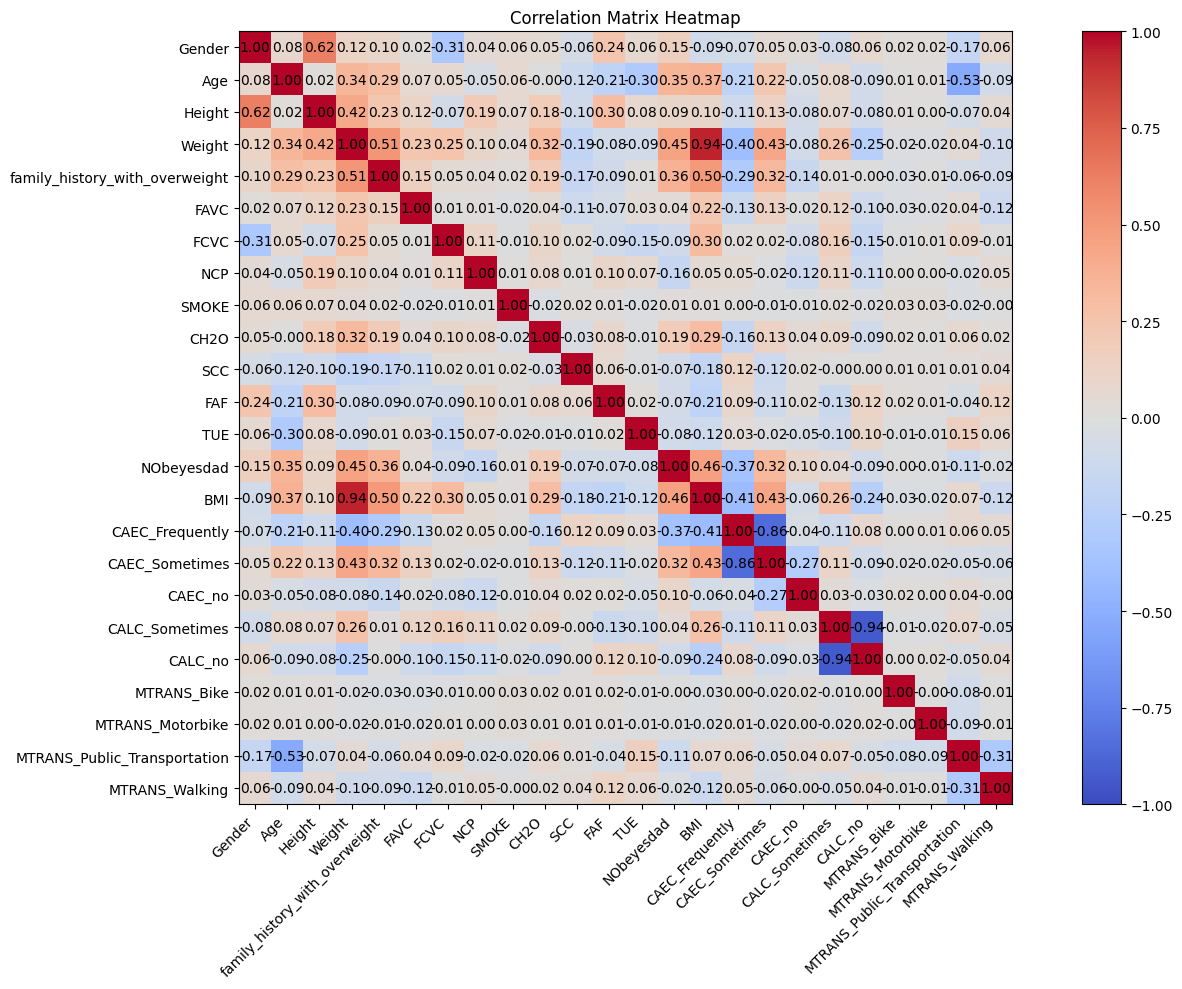

In [ ]:
correlation_matrix = df_encoded.corr()
# correlation Matrix Visualisation using Heatmap...
corr  = correlation_matrix
fig, ax = plt.subplots(figsize=(15, 10))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix Heatmap')
fig.tight_layout()
plt.show()


## Describe Correlations with Target

### Subtask:
Explain the correlation of each feature with the target variable `NObeyesdad`, highlighting the strongest positive and negative relationships.


In [ ]:
correlation_with_target = corr['NObeyesdad'].sort_values(ascending=False)
print("Correlation of features with NObeyesdad (sorted):")
print(correlation_with_target)

Correlation of features with NObeyesdad (sorted):
NObeyesdad                        1.000000
BMI                               0.463785
Weight                            0.446434
family_history_with_overweight    0.362614
Age                               0.347057
CAEC_Sometimes                    0.321791
CH2O                              0.185656
Gender                            0.154799
CAEC_no                           0.097913
Height                            0.093940
CALC_Sometimes                    0.042913
FAVC                              0.037373
SMOKE                             0.013318
MTRANS_Bike                      -0.000132
MTRANS_Motorbike                 -0.011225
MTRANS_Walking                   -0.024135
SCC                              -0.071811
FAF                              -0.073577
TUE                              -0.079938
CALC_no                          -0.085759
FCVC                             -0.094261
MTRANS_Public_Transportation     -0.112866
NCP 

** Relative Moderate Positive Correlations:**
*   `BMI`   (0.429686)
*   `CAEC_Sometimes` (0.316962): 'Consumption of food between meals sometimes' shows a positive correlation,
*   `family_history_with_overweight` (0.313667)
*   `Age` (0.259422)

**Relative moderate-weak Negative Correlations:**
*   `CAEC_Frequently` ( -0.351827)
*   `CALC_no ` ( -0.134716)
*   `FAF` (Physical Activity Frequency) (-0.129564)
*   `NCP` (Number of main meals) (-0.092616)

**Weak or Negligible Correlations (absolute correlation values close to 0):**
*   `MTRANS_Public_Transportation` ( -0.047784), `SMOKE` (-0.023341), `Gender` (0.014699), `FCVC` (0.041023),


In [ ]:
# Detection of significance of correlation with the Target Feature.
from scipy.stats import spearmanr

target = "NObeyesdad"
results = []

for col in df_encoded.columns:
    if col != target:
        r, p_value = spearmanr(df_encoded[target], df_encoded[col])
        r_squared = r**2
        significance = "Significant" if p_value < 0.05 else "Not significant"

        results.append((col, r, r_squared, p_value, significance))

# Print results
print("Correlation, R-squared, and Significance for NObeyesdad")
for col, r, r2, p, sig in results:
    print(f"{target} <--> {col} | r = {r:.3f} | R² = {r2:.3f} | p = {p:.4f} | {sig}")


Correlation, R-squared, and Significance for NObeyesdad
NObeyesdad <--> Gender | r = 0.157 | R² = 0.025 | p = 0.0000 | Significant
NObeyesdad <--> Age | r = 0.316 | R² = 0.100 | p = 0.0000 | Significant
NObeyesdad <--> Height | r = 0.083 | R² = 0.007 | p = 0.0000 | Significant
NObeyesdad <--> Weight | r = 0.370 | R² = 0.137 | p = 0.0000 | Significant
NObeyesdad <--> family_history_with_overweight | r = 0.312 | R² = 0.097 | p = 0.0000 | Significant
NObeyesdad <--> FAVC | r = 0.013 | R² = 0.000 | p = 0.0613 | Not significant
NObeyesdad <--> FCVC | r = -0.127 | R² = 0.016 | p = 0.0000 | Significant
NObeyesdad <--> NCP | r = -0.236 | R² = 0.056 | p = 0.0000 | Significant
NObeyesdad <--> SMOKE | r = 0.007 | R² = 0.000 | p = 0.3124 | Not significant
NObeyesdad <--> CH2O | r = 0.159 | R² = 0.025 | p = 0.0000 | Significant
NObeyesdad <--> SCC | r = -0.046 | R² = 0.002 | p = 0.0000 | Significant
NObeyesdad <--> FAF | r = -0.064 | R² = 0.004 | p = 0.0000 | Significant
NObeyesdad <--> TUE | r = -

# prepare the dataset ( Extract X (df_features) and Y (df_target))

In [ ]:

X_data = df_encoded.drop(columns=['NObeyesdad'])
# Target Feature
Y_data = df_encoded['NObeyesdad']
X_data.head() , Y_data.head()

(   Gender        Age    Height      Weight  family_history_with_overweight  \
 0       1  24.443011  1.699998   81.669950                               1   
 1       0  18.000000  1.560000   57.000000                               1   
 2       0  18.000000  1.711460   50.165754                               1   
 3       0  20.952737  1.710730  131.274851                               1   
 4       1  31.641081  1.914186   93.798055                               1   
 
    FAVC      FCVC       NCP  SMOKE      CH2O  ...        BMI  CAEC_Frequently  \
 0     1  2.000000  2.983297      0  2.763573  ...  28.259565              0.0   
 1     1  2.000000  3.000000      0  2.000000  ...  23.422091              1.0   
 2     1  1.880534  1.411685      0  1.910378  ...  17.126706              0.0   
 3     1  3.000000  3.000000      0  1.674061  ...  44.855798              0.0   
 4     1  2.679664  1.971472      0  1.979848  ...  25.599151              0.0   
 
    CAEC_Sometimes  CAEC_no  C

# Split the dataset to train / test split with weight 80/20

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42 , shuffle=True)
X_train.shape , X_test.shape , Y_train.shape, Y_test.shape






# Numerical columns (continuous, float64) to be standardized
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Ordinal/Binary columns (label encoded to 0/1, int64) to be min-max scaled.
# CAEC, CALC, MTRANS are one-hot encoded, so they are excluded from this list.
# NObeyesdad is the target, so it's excluded from scaling.
ordinal_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

categorical_cols = ['gender', 'family_history_with_overweight', 'SMOKE', 'MTRANS']

# Initialize scalers
scaler_num = StandardScaler()  # For continuous features
scaler_ord = MinMaxScaler()    # For ordinal features (keeps 0-1 range)

# Apply scaling to the defined column groups and assign back to the DataFrame
X_train[numeric_cols] = scaler_num.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler_num.transform(X_test[numeric_cols])

X_train[ordinal_cols] = scaler_num.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = scaler_num.transform(X_test[ordinal_cols])

#X_train['BMI_x_FAF'] = X_train['BMI'] * X_train['FAF']
#X_test['BMI_x_FAF'] = X_test['BMI'] * X_test['FAF']

X_train['Diet_Risk'] = X_train['FAVC'] * (4 - X_train['FCVC'])  # High-calorie, low-veg penalty
X_test['Diet_Risk'] = X_test['FAVC'] * (4 - X_test['FCVC'])

## Learning_curve Function

In [ ]:
# Function to plot learning curves
def plot_learning_curve(estimator, X, y, title="Learning Curve"):
    """
    Plot learning curves to diagnose overfitting/underfitting
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=5,  # 5-fold cross-validation
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),  # 10 points from 10% to 100% of data
        scoring='accuracy' )

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training accuracy', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    plt.plot(train_sizes, test_mean, label='Validation accuracy', color='red', marker='s')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')

    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Diagnosis
    final_train_acc = train_mean[-1]
    final_val_acc = test_mean[-1]
    gap = final_train_acc - final_val_acc

    print(f"\n--- Model Diagnosis ---")
    print(f"Final Training Accuracy: {final_train_acc}")
    print(f"Final Validation Accuracy: {final_val_acc}")
    print(f"Train-Validation Gap: {gap:.4f}")

    if gap > 0.1:
        print("HIGH VARIANCE (Overfitting): Training accuracy is significantly higher than validation accuracy")
        print("Suggestions: Use regularization, get more data, or reduce model complexity")
    elif final_val_acc < 0.7:
        print("HIGH BIAS (Underfitting): Both accuracies are low")
        print("Suggestions: Use a more complex model, add features, or train longer")
    else:
        print("Model appears to be well-fitted")

# Classification Models...

###1. Logestic Regression Model max_iter = 1000 ...

The LR Accuracy max_itr=1000: 0.9128131021194605


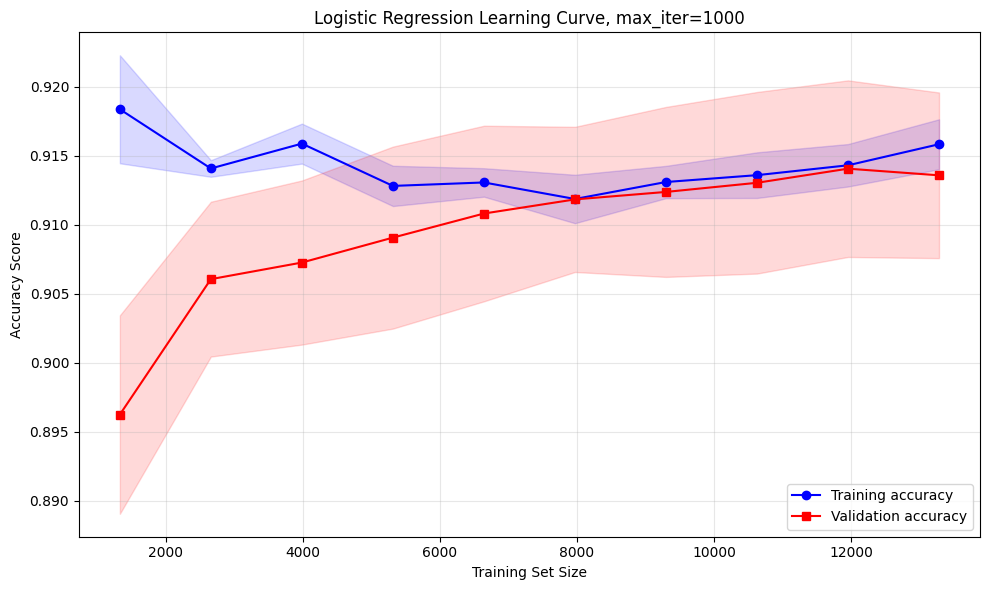


--- Model Diagnosis ---
Final Training Accuracy: 0.9158386028304728
Final Validation Accuracy: 0.9135855948164137
Train-Validation Gap: 0.0023
Model appears to be well-fitted


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
# Define model
LRmodel_1000 = LogisticRegression(max_iter=1000, class_weight='balanced',      # 🔑 Auto-weights inverse to class frequencies
    multi_class='multinomial',solver='newton-cg',penalty='l2', C =100.0,
                                  n_jobs = -1)

# ---------------------------
# 1) Train the model
# ---------------------------
LRmodel_1000.fit(X_train, Y_train)

# ---------------------------
# 2) Predict
# ---------------------------
y_LR1000_pred = LRmodel_1000.predict(X_test)

# Evaluate predictions
print(f"The LR Accuracy max_itr=1000: {accuracy_score(Y_test, y_LR1000_pred)}")

# # Evaluate predictions
# print("Test Accuracy:", accuracy_score(Y_test, y_pred))
# print("\nClassification Report:\n", classification_report(Y_test, y_pred))

# ---------------------------
# 3) Learning Curve
# ---------------------------
plot_learning_curve(LRmodel_1000, X_train, Y_train, title="Logistic Regression Learning Curve, max_iter=1000")

## 2. Logestic Regression Model max_iter = 5000 ...

The LR Accuracy max_itr=5000: 0.9128131021194605


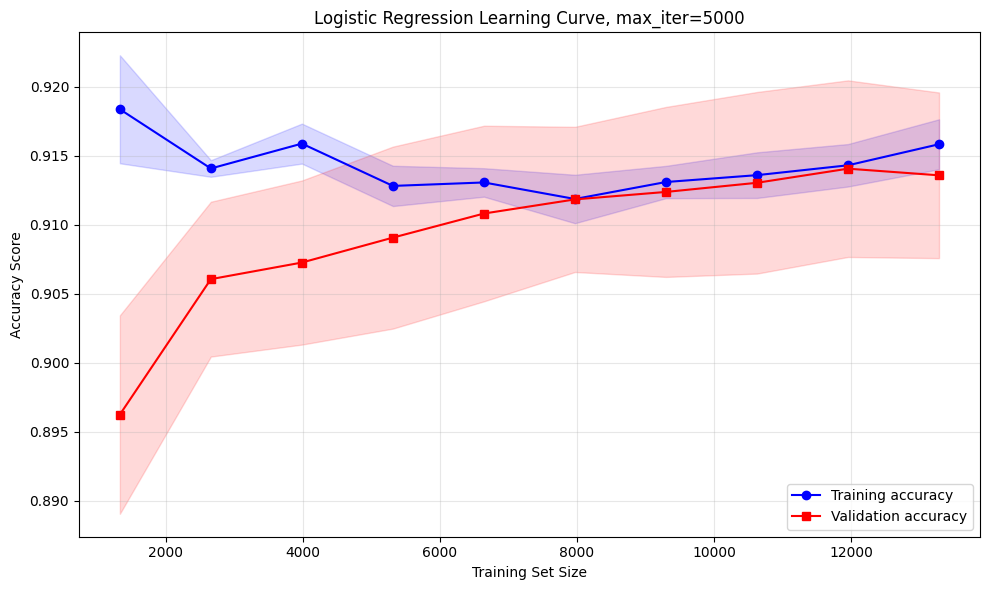


--- Model Diagnosis ---
Final Training Accuracy: 0.9158386028304728
Final Validation Accuracy: 0.9135855948164137
Train-Validation Gap: 0.0023
Model appears to be well-fitted


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define model
LRmodel_5000 = LogisticRegression(max_iter=5000, class_weight='balanced',      # 🔑 Auto-weights inverse to class frequencies
    multi_class='multinomial',solver='newton-cg',penalty='l2', C =100.0,
                                  n_jobs = -1)

# ---------------------------
# 1) Train the model
# ---------------------------
LRmodel_5000.fit(X_train, Y_train)

# ---------------------------
# 2) Predict
# ---------------------------
y_LR5000_pred = LRmodel_5000.predict(X_test)

# Evaluate predictions
print(f"The LR Accuracy max_itr=5000: {accuracy_score(Y_test, y_LR5000_pred)}")

# # Evaluate predictions
# print("Test Accuracy:", accuracy_score(Y_test, y_pred))
# print("\nClassification Report:\n", classification_report(Y_test, y_pred))

# ---------------------------
# 3) Learning Curve
# ---------------------------
plot_learning_curve(LRmodel_5000, X_train, Y_train, title="Logistic Regression Learning Curve, max_iter=5000")

####installing XGBoost library...

In [ ]:
!pip install xgboost

## 3. XGBoost Model [Default Hyperparameter]

The XGBoost Default Accuracy: 0.9340077071290944


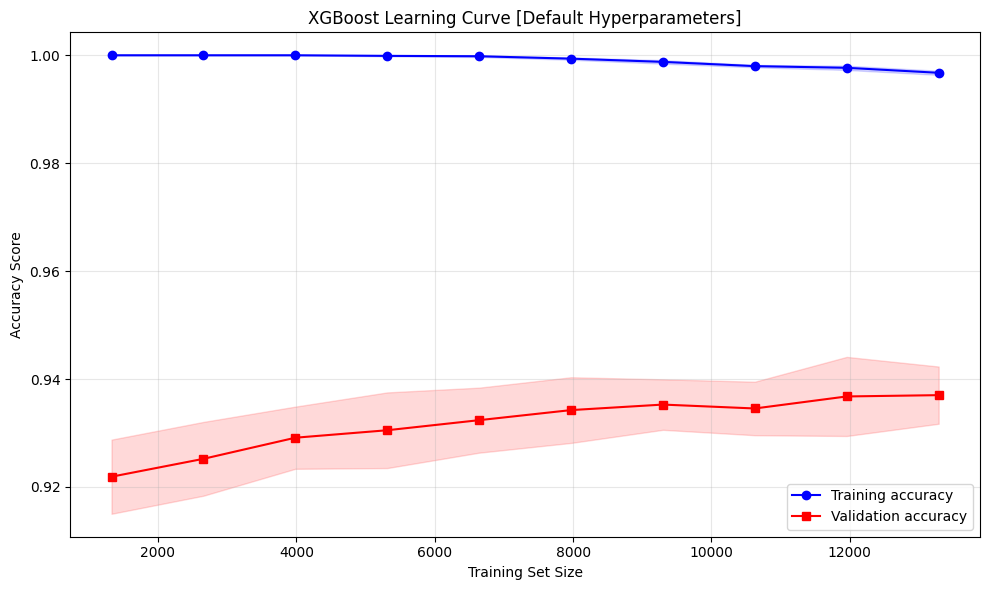


--- Model Diagnosis ---
Final Training Accuracy: 0.9967479674796748
Final Validation Accuracy: 0.9370110770476894
Train-Validation Gap: 0.0597
Model appears to be well-fitted
Macro F1: 0.920
Balanced Acc: 0.922


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np # Import numpy for array conversion
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score


sample_weights = compute_sample_weight(class_weight='balanced', y=Y_train)

# Define model
XGBmodel_default = XGBClassifier(eval_metric="mlogloss")

# 1) Train the model
XGBmodel_default.fit(X_train, Y_train, sample_weight=sample_weights)

# 2) Predict
y_XGB_default_pred = XGBmodel_default.predict(X_test)

print(f"The XGBoost Default Accuracy: {accuracy_score(Y_test, y_XGB_default_pred)}")

# 3) Learning Curve
plot_learning_curve(XGBmodel_default, X_train, Y_train, title="XGBoost Learning Curve [Default Hyperparameters]")
print(f"Macro F1: {f1_score(Y_test, y_XGB_default_pred, average='macro'):.3f}")
print(f"Balanced Acc: {balanced_accuracy_score(Y_test, y_XGB_default_pred):.3f}")

In [ ]:
gain_importances = XGBmodel_default.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame({
    'feature': list(gain_importances.keys()),
    'gain': list(gain_importances.values())
}).sort_values('gain', ascending=False)
print(gain_df.head(10))

                           feature       gain
13                             BMI  30.710289
3                           Weight   3.490870
16                         CAEC_no   2.226333
14                 CAEC_Frequently   1.931069
7                              NCP   1.832213
0                           Gender   1.791048
5                             FAVC   1.593370
18                         CALC_no   1.592843
12                             TUE   1.414789
4   family_history_with_overweight   1.374407


In [ ]:
# Using 'gain' (or 'weight')
gain_df['cumulative_gain'] = gain_df['gain'].cumsum() / gain_df['gain'].sum()
important_features = gain_df[gain_df['cumulative_gain'] <= 0.95]['feature'].tolist()
print(f"Keeping {important_features} features covering 95% of gain")

Keeping ['BMI', 'Weight', 'CAEC_no', 'CAEC_Frequently', 'NCP', 'Gender', 'FAVC', 'CALC_no', 'TUE', 'family_history_with_overweight', 'CH2O', 'Age', 'FAF'] features covering 95% of gain


In [ ]:
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]
new_model = XGBClassifier(n_estimators=100, random_state=42)
new_model.fit(X_train_reduced, Y_train, sample_weight=sample_weights)

y_pred = new_model.predict(X_test_reduced)
new_accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy with {len(important_features)} features: {new_accuracy:.4f}")

Accuracy with 13 features: 0.9340


# 4. XGBoost Model [Adjusted Hyperparameters]
###

Generating learning curves for XGBoost...


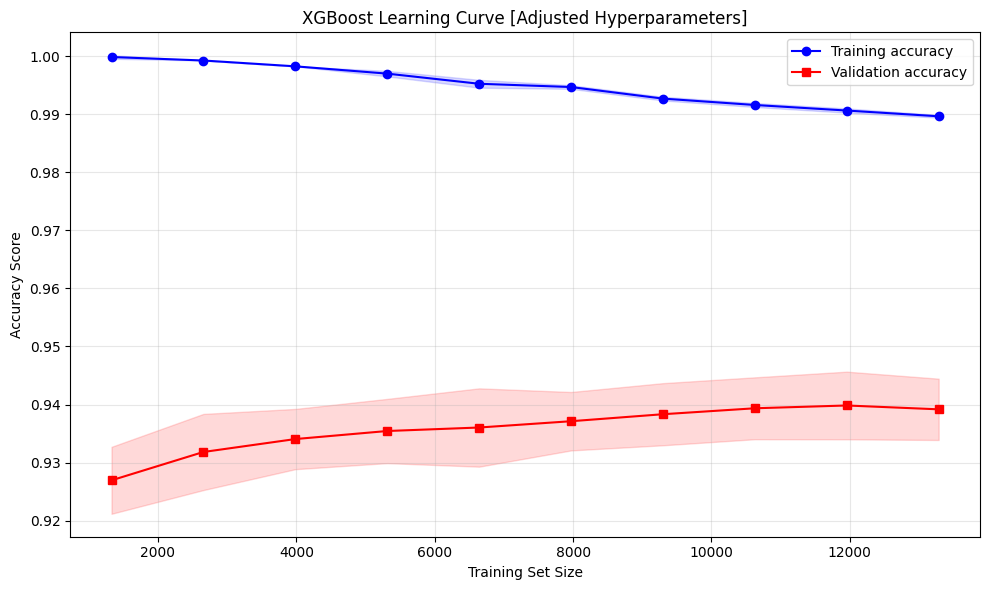


--- Model Diagnosis ---
Final Training Accuracy: 0.9896416741945198
Final Validation Accuracy: 0.9391789174430644
Train-Validation Gap: 0.0505
Model appears to be well-fitted

--- Final Test Results ---
XGBoost (Adjusted) Accuracy: 0.9386
Logistic Regression max_iter=5000 Accuracy: 0.9128
Macro F1: 0.920
Balanced Acc: 0.922


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score


sample_weights = compute_sample_weight(class_weight='balanced', y=Y_train)


# Define XGBoost model
XGBmodel_optimized = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42,
    learning_rate=0.05,
    n_estimators=500,
    max_depth=7,
    subsample=0.4,
    colsample_bytree=0.4)

# 1. Train on full training set
XGBmodel_optimized.fit(X_train, Y_train, sample_weight=sample_weights)

# 2.  Make predictions
y_XGB_optimized_pred = XGBmodel_optimized.predict(X_test)

# 3. Plot learning curve BEFORE final training
print("Generating learning curves for XGBoost...")
plot_learning_curve(XGBmodel_optimized, X_train, Y_train, title="XGBoost Learning Curve [Adjusted Hyperparameters]")



# Print final results
print(f"\n--- Final Test Results ---")
print(f"XGBoost (Adjusted) Accuracy: {accuracy_score(Y_test, y_XGB_optimized_pred):.4f}")
print(f"Logistic Regression max_iter=5000 Accuracy: {accuracy_score(Y_test, y_LR5000_pred):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_XGB_default_pred, average='macro'):.3f}")
print(f"Balanced Acc: {balanced_accuracy_score(Y_test, y_XGB_default_pred):.3f}")

## 5. RandomForest Model [Default Hyperparameter]

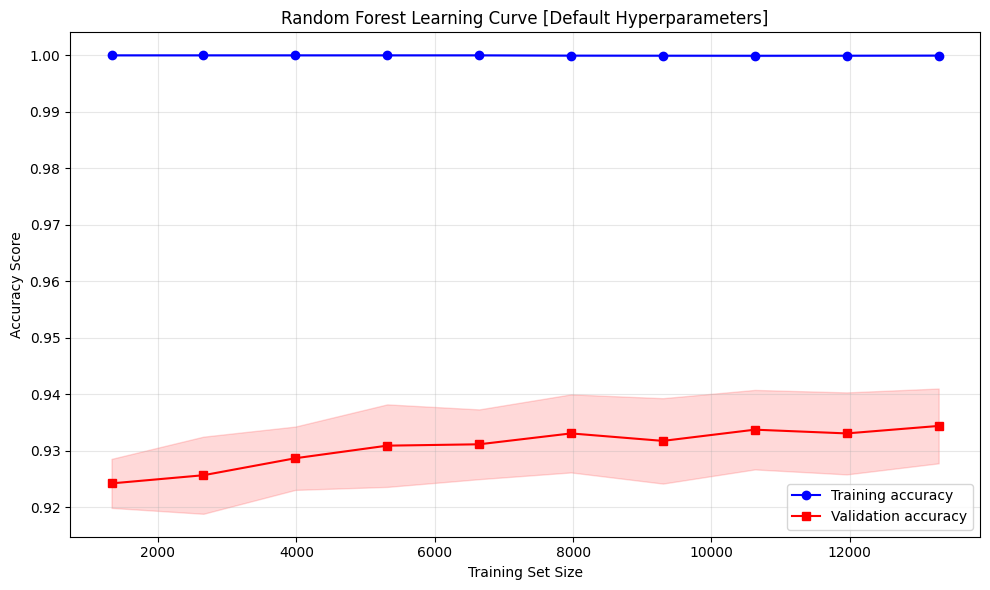


--- Model Diagnosis ---
Final Training Accuracy: 0.9999548328816621
Final Validation Accuracy: 0.9343613996712581
Train-Validation Gap: 0.0656
Model appears to be well-fitted
Random Forest Default Accuracy: 0.9344894026974951


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# Define RandomForest model [Default Hyperparameters] ...
rfmodel_default = RandomForestClassifier(random_state=42,class_weight='balanced')
# 1. Train the model
rfmodel_default.fit(X_train , Y_train)
# 2. Predict
y_RF_default_pred = rfmodel_default.predict(X_test)


#3. Plotting learning curve
plot_learning_curve(rfmodel_default, X_train, Y_train, title="Random Forest Learning Curve [Default Hyperparameters]")


#printing Final accuracy Score of RF model
print(f"Random Forest Default Accuracy: {accuracy_score(Y_test, y_RF_default_pred)}")

# 6. RandomForest Model[Adjusted Hyperparameters]

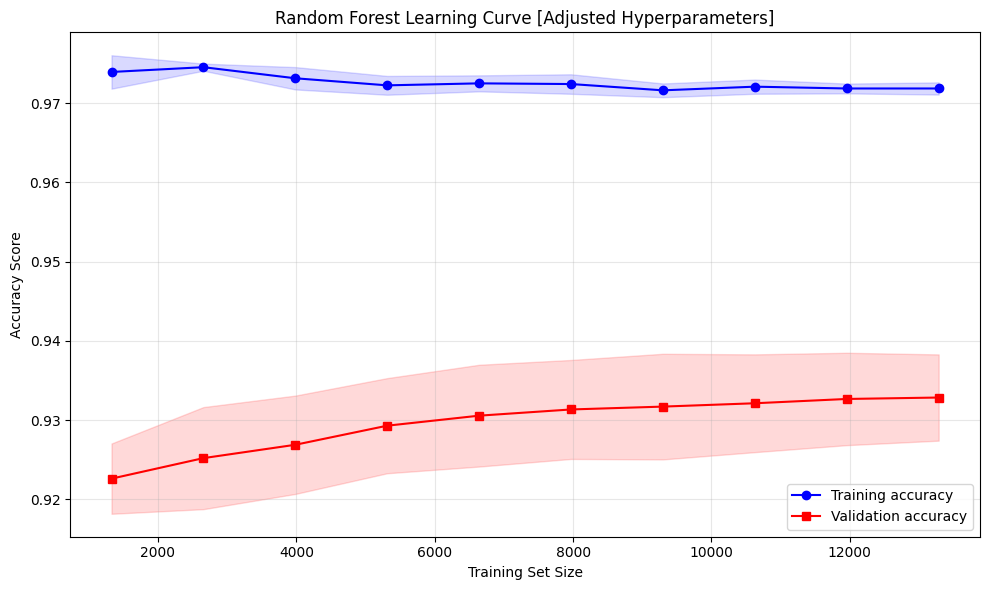


--- Model Diagnosis ---
Final Training Accuracy: 0.9718608852755193
Final Validation Accuracy: 0.9328558290599963
Train-Validation Gap: 0.0390
Model appears to be well-fitted
Random Forest (Adjusted) Accuracy: 0.9342485549132948


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define RandomForest model [Updated Hyperparameters] ...
rfmodel_optimized = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced')
# 1. Train the model
rfmodel_optimized.fit(X_train , Y_train)
# 2. Predict
y_RF_optimized_pred = rfmodel_optimized.predict(X_test)


#3. Plotting learning curve
plot_learning_curve(rfmodel_optimized, X_train, Y_train, title="Random Forest Learning Curve [Adjusted Hyperparameters]")


#printing Final accuracy Score of RF model
print(f"Random Forest (Adjusted) Accuracy: {accuracy_score(Y_test, y_RF_optimized_pred)}")

# Model Comparison and Visualization

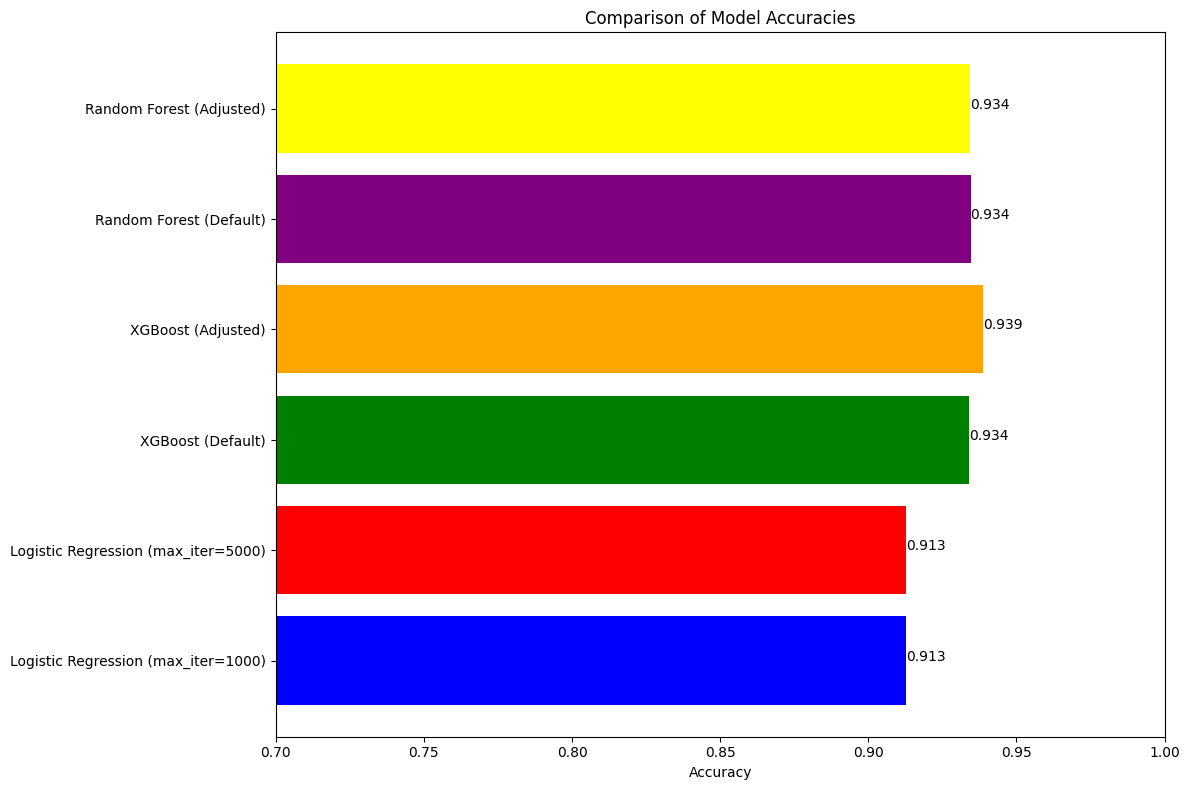

Final models accuracies:
Logistic Regression (max_iter=1000): 0.9128
Final models accuracies:
Logistic Regression (max_iter=5000): 0.9128
Final models accuracies:
XGBoost (Default): 0.9340
Final models accuracies:
XGBoost (Adjusted): 0.9386
Final models accuracies:
Random Forest (Default): 0.9345
Final models accuracies:
Random Forest (Adjusted): 0.9342


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Dictionary to store accuracies of your six models
model_accuracies = {
    "Logistic Regression (max_iter=1000)": accuracy_score(Y_test, y_LR1000_pred),
    "Logistic Regression (max_iter=5000)": accuracy_score(Y_test, y_LR5000_pred),
    "XGBoost (Default)": accuracy_score(Y_test, y_XGB_default_pred),
    "XGBoost (Adjusted)": accuracy_score(Y_test, y_XGB_optimized_pred),
    "Random Forest (Default)": accuracy_score(Y_test, y_RF_default_pred),
    "Random Forest (Adjusted)": accuracy_score(Y_test, y_RF_optimized_pred)
}

# Convert to lists for plotting
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

# --- Visualization ---
plt.figure(figsize=(12, 8))
plt.barh(models, accuracies, color=["blue","red","green","orange","purple","yellow"])
plt.xlabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.xlim(0.7, 1)  # adjust range for clarity
for index, value in enumerate(accuracies):
    plt.text(value, index, f"{value:.3f}")
plt.tight_layout()
plt.show()

# Final models acuracies
for model, accuracy in model_accuracies.items():
    print(f"Final models accuracies:")
    print(f"{model}: {accuracy:.4f}")


